In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

In [81]:
df = pd.read_csv("abalone.csv", header=None)

df.columns = [
    "Sex",
    "Length",
    "Diameter",
    "Height",
    "Whole weight",
    "Shucked weight",
    "Viscera weight",
    "Shell weight",
    "Rings"
]

print(df.shape)
df.head()

(4177, 9)


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [82]:
df.shape

(4177, 9)

In [83]:
df.head(10)

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
5,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.330,20
7,F,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.260,16
8,M,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.165,9
9,F,0.550,0.440,0.150,0.8945,0.3145,0.1510,0.320,19


In [84]:
df.tail(10)

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
4167,M,0.500,0.380,0.125,0.5770,0.2690,0.1265,0.1535,9
4168,F,0.515,0.400,0.125,0.6150,0.2865,0.1230,0.1765,8
4169,M,0.520,0.385,0.165,0.7910,0.3750,0.1800,0.1815,10
4170,M,0.550,0.430,0.130,0.8395,0.3155,0.1955,0.2405,10
4171,M,0.560,0.430,0.155,0.8675,0.4000,0.1720,0.2290,8
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4176,M,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [85]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [86]:
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

In [87]:
df.duplicated().sum()


np.int64(0)

In [88]:
df['Age'] = df['Rings'] + 1.5

In [89]:
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,16.5
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,8.5
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,10.5
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,11.5
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,8.5


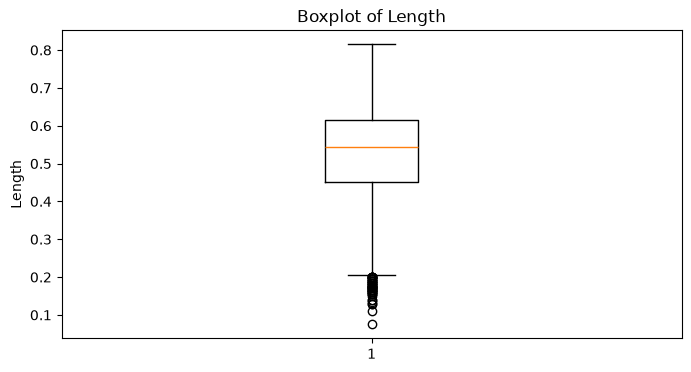

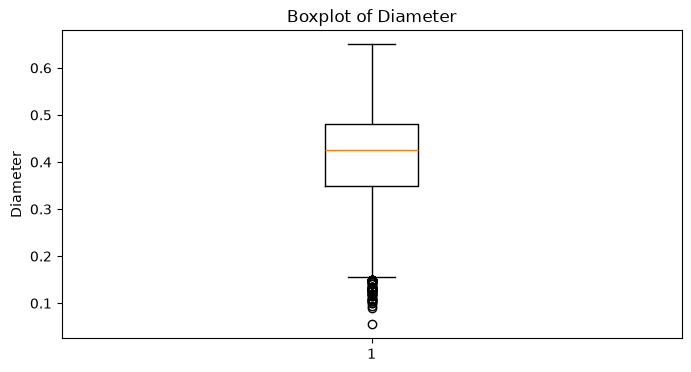

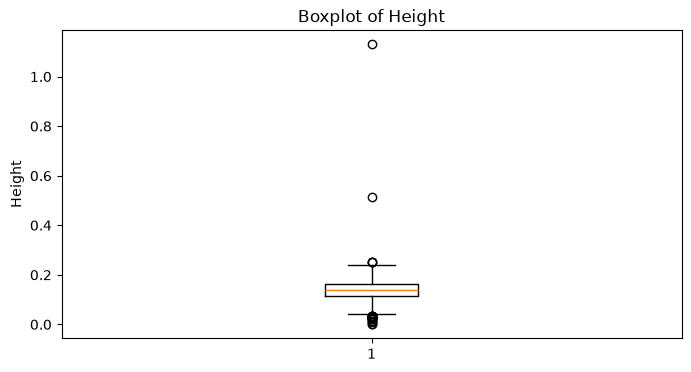

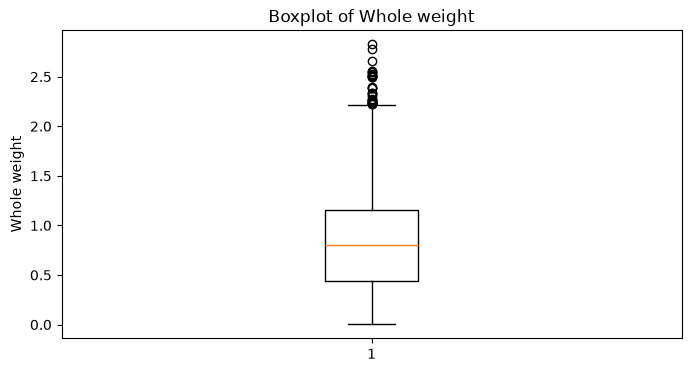

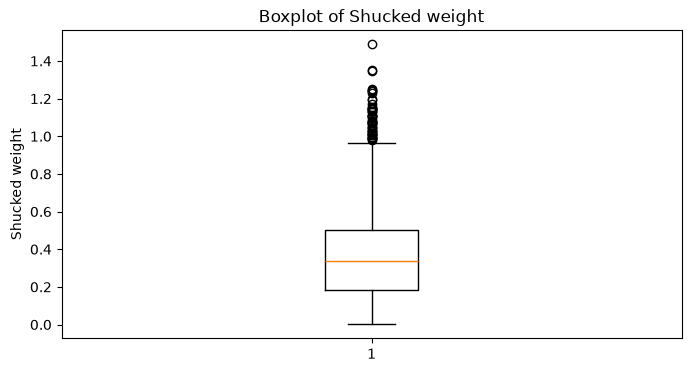

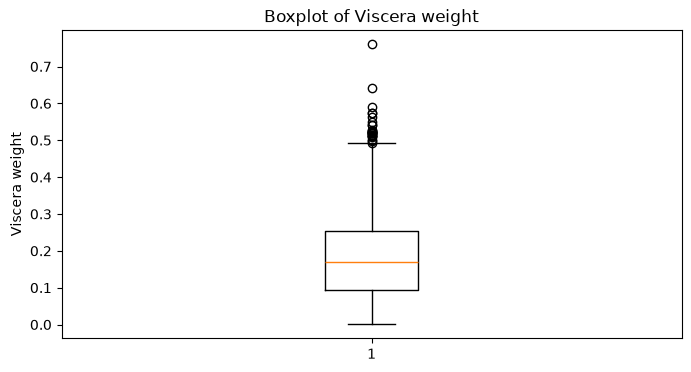

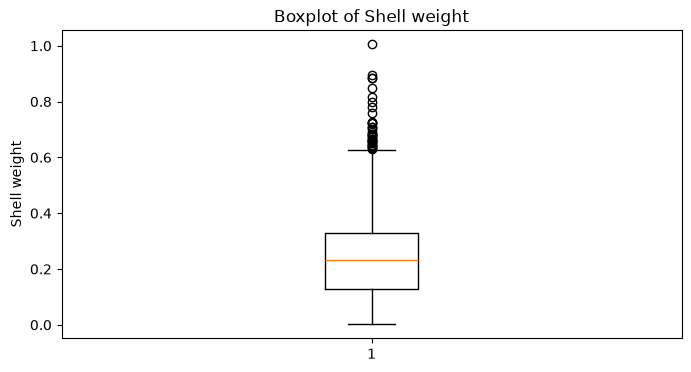

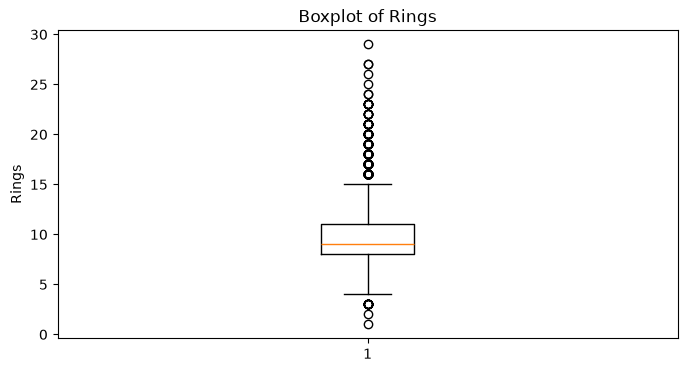

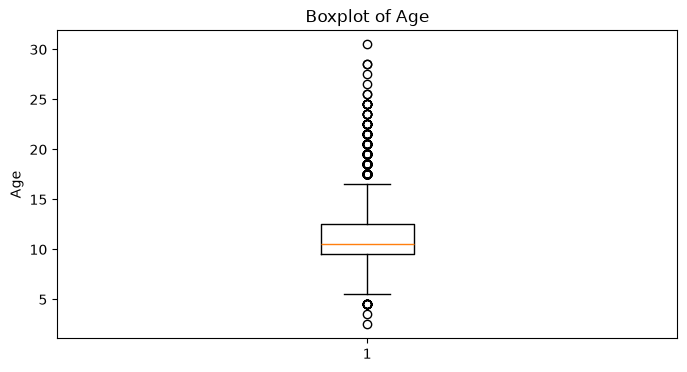

In [90]:
numerical_columns = [
    "Length",
    "Diameter",
    "Height",
    "Whole weight",
    "Shucked weight",
    "Viscera weight",
    "Shell weight",
    "Rings",
    "Age"
]

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column])
    plt.title("Boxplot of " + column)
    plt.ylabel(column)
    plt.show()

In [91]:
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    percentage = (len(outliers) / len(df)) * 100

    print(column, ":", len(outliers), "outliers",
          "(", round(percentage, 2), "% )")

Length : 49 outliers ( 1.17 % )
Diameter : 59 outliers ( 1.41 % )
Height : 29 outliers ( 0.69 % )
Whole weight : 30 outliers ( 0.72 % )
Shucked weight : 48 outliers ( 1.15 % )
Viscera weight : 26 outliers ( 0.62 % )
Shell weight : 35 outliers ( 0.84 % )
Rings : 278 outliers ( 6.66 % )
Age : 278 outliers ( 6.66 % )


In [92]:

Q1 = df['Height'].quantile(0.25)
Q3 = df['Height'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Height'] >= lower_bound) & (df['Height'] <= upper_bound)]

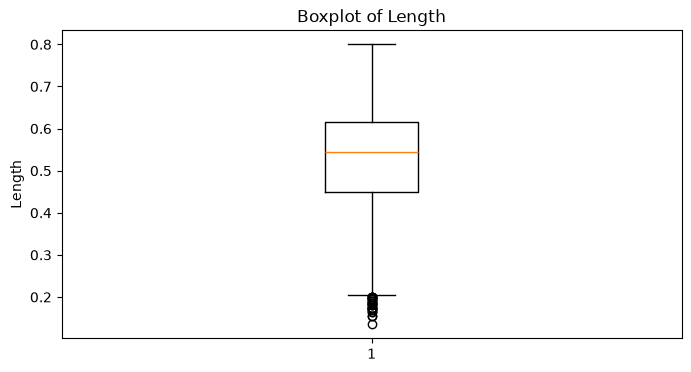

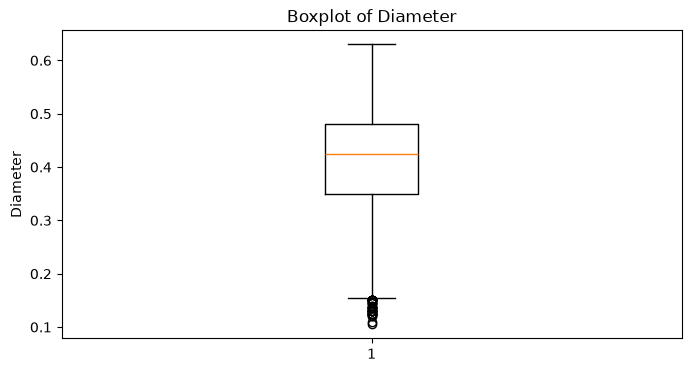

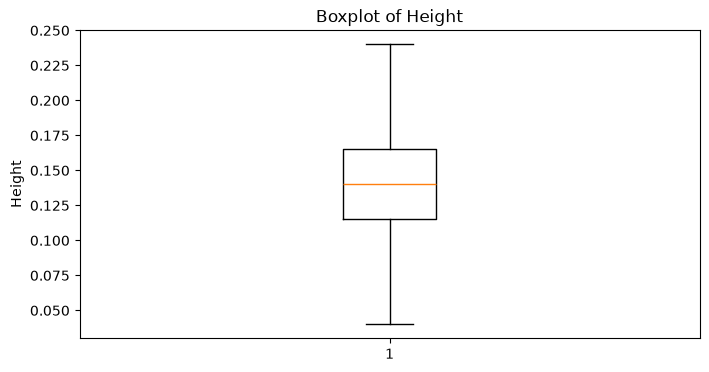

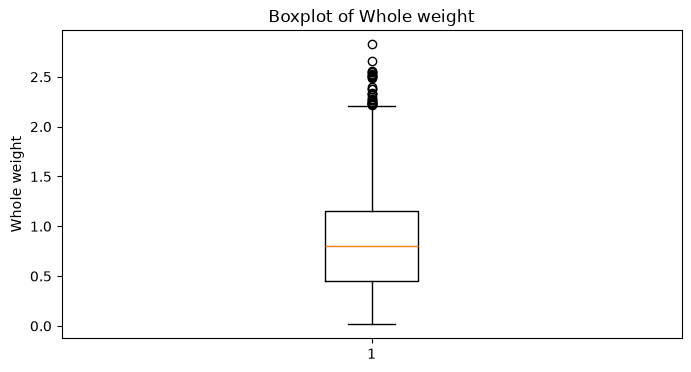

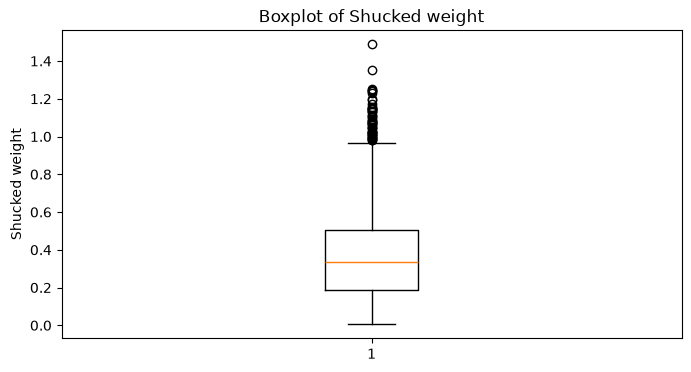

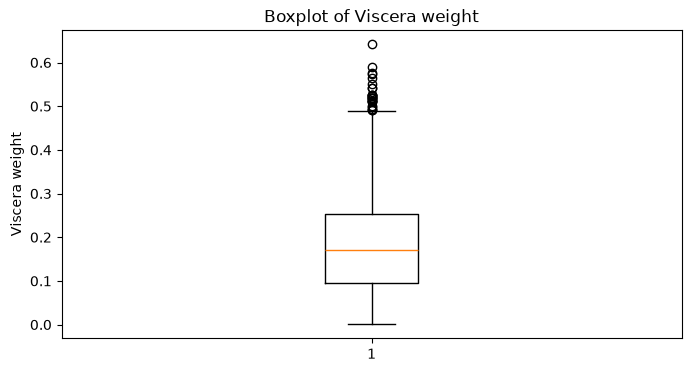

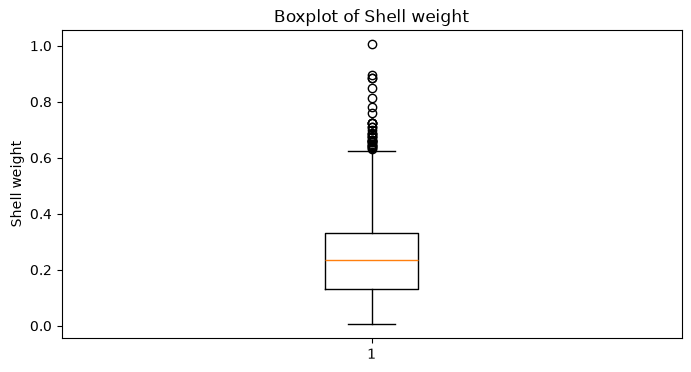

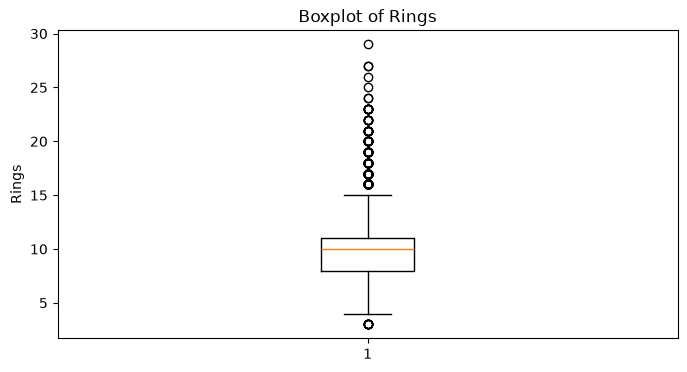

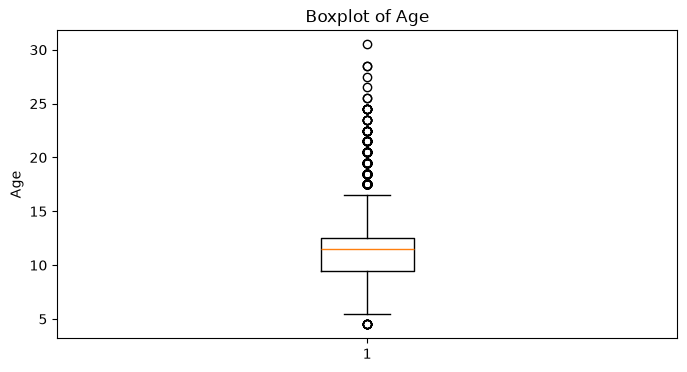

In [93]:
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column])
    plt.title("Boxplot of " + column)
    plt.ylabel(column)
    plt.show()

In [94]:

Q1 = df['Viscera weight'].quantile(0.25)
Q3 = df['Viscera weight'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Viscera weight'] >= lower_bound) & (df['Viscera weight'] <= upper_bound)]

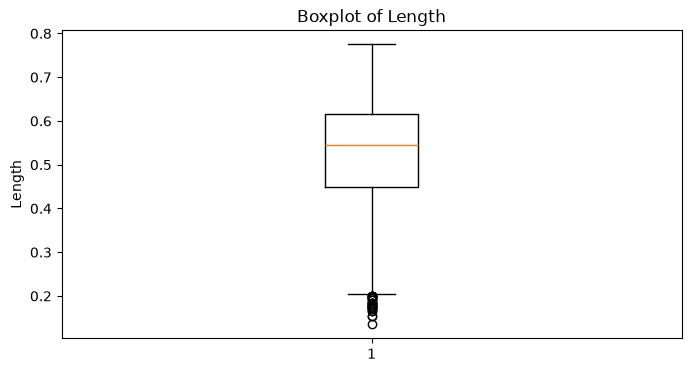

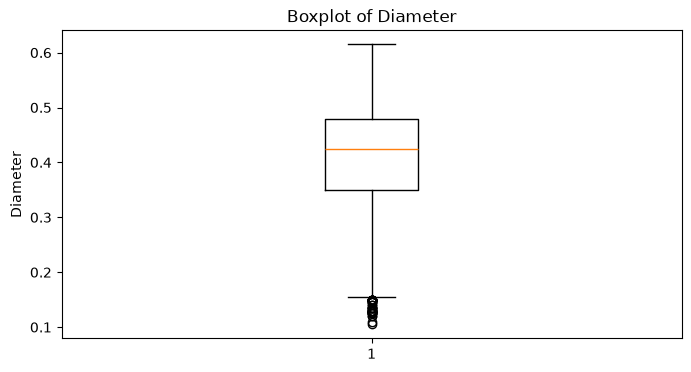

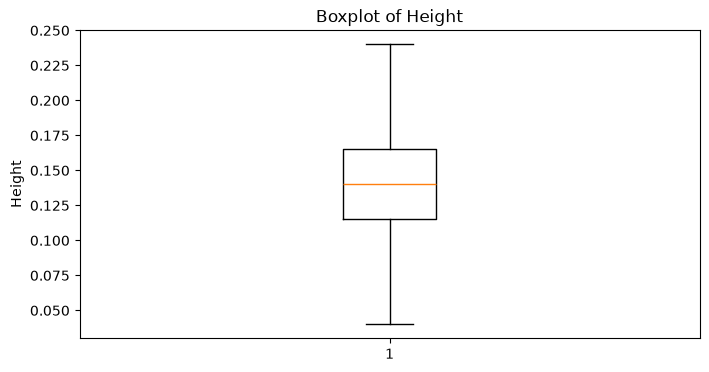

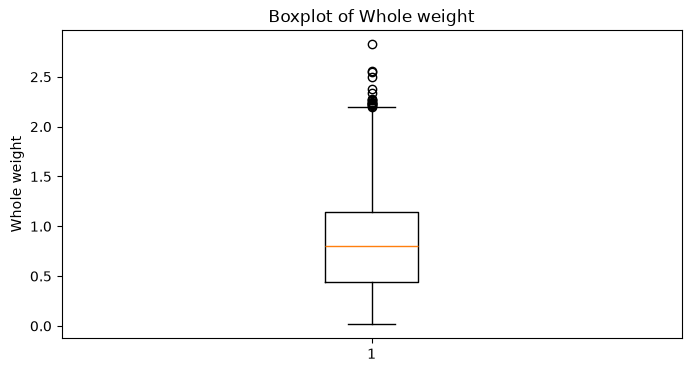

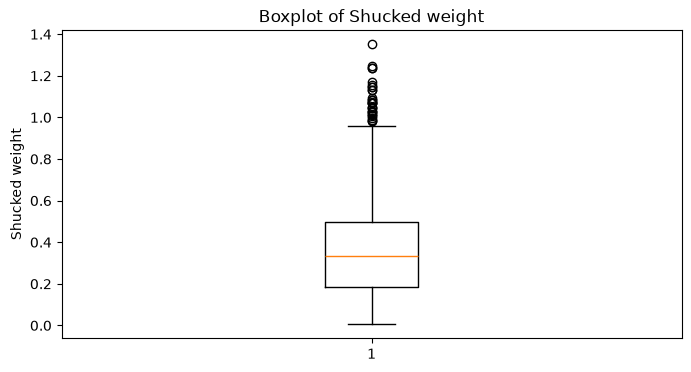

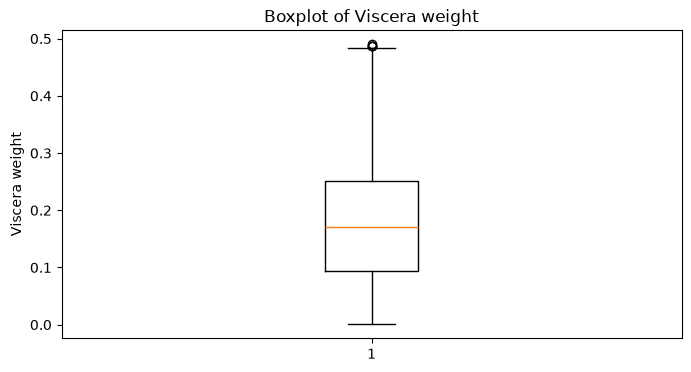

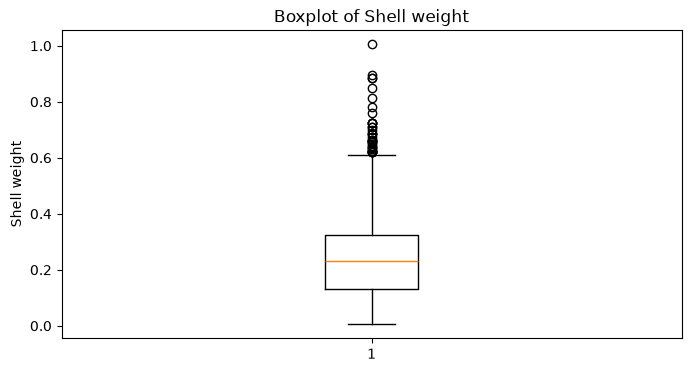

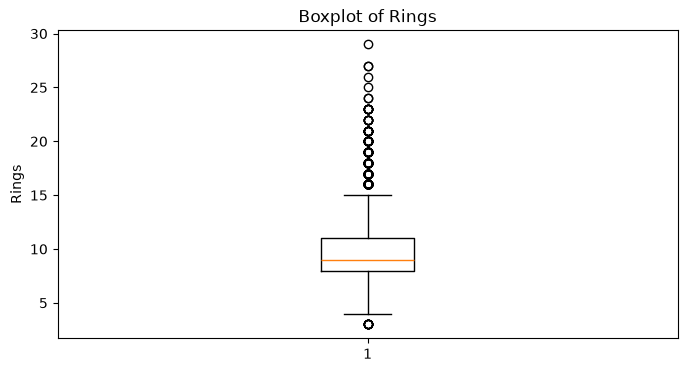

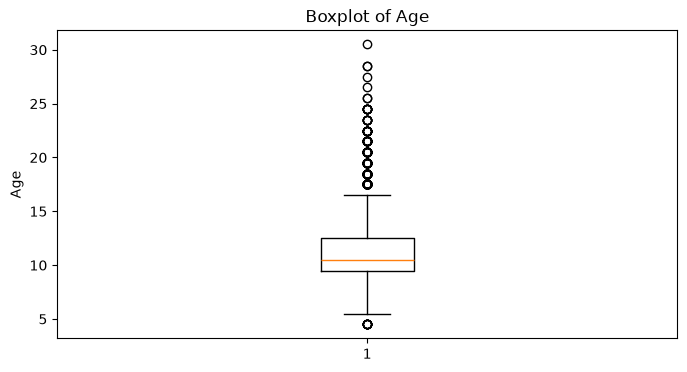

In [95]:
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column])
    plt.title("Boxplot of " + column)
    plt.ylabel(column)
    plt.show()

In [96]:
df.shape

(4121, 10)

In [97]:
df = pd.get_dummies(df, columns=['Sex'], drop_first=True, dtype=int)

In [98]:
print(df.dtypes)

Length            float64
Diameter          float64
Height            float64
Whole weight      float64
Shucked weight    float64
Viscera weight    float64
Shell weight      float64
Rings               int64
Age               float64
Sex_I               int64
Sex_M               int64
dtype: object


In [99]:
df.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,16.5,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,8.5,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,10.5,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,11.5,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,8.5,1,0


In [100]:
df.columns


Index(['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings', 'Age', 'Sex_I', 'Sex_M'],
      dtype='str')

In [101]:
X = df.drop(columns=['Age', 'Rings'])
y = df['Age']

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [103]:
print(X_train.columns.tolist())

['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'Sex_I', 'Sex_M']


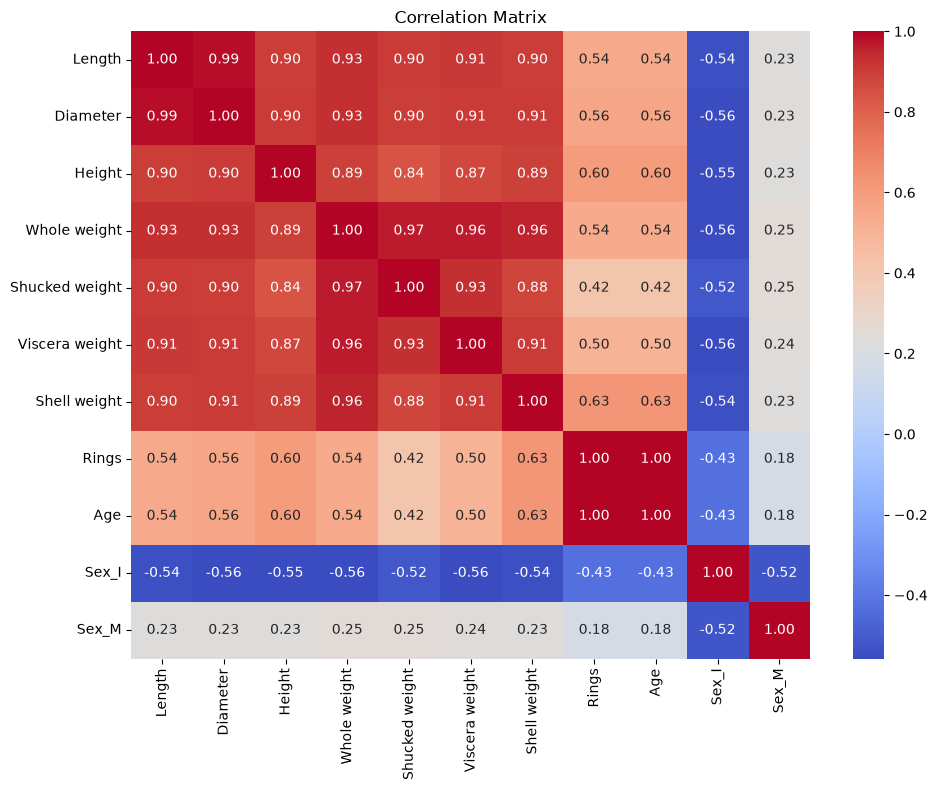

In [104]:

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [105]:
num_cols = ['Diameter','Length','Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [106]:


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


MAE: 1.5938
MSE: 5.0379
RMSE: 2.2445
R²: 0.5561


In [107]:

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial (deg 2) MAE: {mae_poly:.4f}")
print(f"Polynomial (deg 2) MSE: {mse_poly:.4f}")
print(f"Polynomial (deg 2) RMSE: {rmse_poly:.4f}")
print(f"Polynomial (deg 2) R²: {r2_poly:.4f}")
print(f"Feature count after expansion: {X_train_poly.shape[1]}")


Polynomial (deg 2) MAE: 1.5193
Polynomial (deg 2) MSE: 4.7685
Polynomial (deg 2) RMSE: 2.1837
Polynomial (deg 2) R²: 0.5799
Feature count after expansion: 54


In [108]:
print("Train R²:", r2_score(y_train, poly_model.predict(X_train_poly)))
print("Test R²:", r2_score(y_test, y_pred_poly))

Train R²: 0.5866502238566786
Test R²: 0.5798635786839781


In [109]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE: {mae_rf:.4f}")
print(f"Random Forest MSE: {mse_rf:.4f}")
print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Random Forest R²: {r2_rf:.4f}")

print("Train R²:", r2_score(y_train, rf_model.predict(X_train)))
print("Test R²:", r2_score(y_test, y_pred_rf))

Random Forest MAE: 1.5984
Random Forest MSE: 5.2347
Random Forest RMSE: 2.2880
Random Forest R²: 0.5388
Train R²: 0.9372618725688905
Test R²: 0.5387818365066765


In [110]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Train R²:", r2_score(y_train, rf_model.predict(X_train)))
print("Test R²:", r2_score(y_test, y_pred_rf))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Train R²: 0.7048859794603368
Test R²: 0.5542153244865868
Test RMSE: 2.2493507830261423


In [111]:
dt_model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Train R²:", r2_score(y_train, dt_model.predict(X_train)))
print("Test R²:", r2_score(y_test, y_pred_dt))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Train R²: 0.6884471066265552
Test R²: 0.4639436533971142
Test RMSE: 2.4666063315247637


In [112]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("Train R²:", r2_score(y_train, xgb_model.predict(X_train)))
print("Test R²:", r2_score(y_test, y_pred_xgb))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

Train R²: 0.738373475253677
Test R²: 0.5524216707353313
Test RMSE: 2.2538714703527414


In [113]:
results = {
    "Linear Regression": (y_test, model.predict(X_test)),
    "Polynomial (deg 2)": (y_test, poly_model.predict(X_test_poly)),
    "Random Forest (tuned)": (y_test, rf_model.predict(X_test)),
    "Decision Tree": (y_test, dt_model.predict(X_test)),
    "XGBoost": (y_test, xgb_model.predict(X_test)),
}

print(f"{'Model':<25}{'MAE':<10}{'MSE':<10}{'RMSE':<10}{'R²':<10}")
print("-" * 65)
for name, (y_true, y_pred) in results.items():
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:<25}{mae:<10.4f}{mse:<10.4f}{rmse:<10.4f}{r2:<10.4f}")

Model                    MAE       MSE       RMSE      R²        
-----------------------------------------------------------------
Linear Regression        1.5938    5.0379    2.2445    0.5561    
Polynomial (deg 2)       1.5193    4.7685    2.1837    0.5799    
Random Forest (tuned)    1.5745    5.0596    2.2494    0.5542    
Decision Tree            1.6947    6.0841    2.4666    0.4639    
XGBoost                  1.5917    5.0799    2.2539    0.5524    


In [124]:
train_r2 = {
    "Linear Regression": r2_score(y_train, model.predict(X_train)),
    "Polynomial (deg 2)": r2_score(y_train, poly_model.predict(X_train_poly)),
    "Random Forest (tuned)": r2_score(y_train, rf_model.predict(X_train)),
    "Decision Tree": r2_score(y_train, dt_model.predict(X_train)),
    "XGBoost": r2_score(y_train, xgb_model.predict(X_train)),
}

print(f"{'Model':<25}{'Train R²':<12}{'Test R²':<12}{'Gap':<10}")
print("-" * 60)
for name, (y_true, y_pred) in results.items():
    test_r2 = r2_score(y_true, y_pred)
    train_r2_val = train_r2[name]
    print(f"{name:<25}{train_r2_val:<12.4f}{test_r2:<12.4f}{(train_r2_val-test_r2):<10.4f}")

Model                    Train R²    Test R²     Gap       
------------------------------------------------------------
Linear Regression        0.5308      0.5561      -0.0253   
Polynomial (deg 2)       0.5867      0.5799      0.0068    
Random Forest (tuned)    0.7049      0.5542      0.1507    
Decision Tree            0.6884      0.4639      0.2245    
XGBoost                  0.7384      0.5524      0.1860    


Shell weight      0.628375
Shucked weight    0.171028
Whole weight      0.055276
Height            0.035680
Viscera weight    0.033967
Diameter          0.030055
Length            0.021954
Sex_I             0.019971
Sex_M             0.003694
dtype: float64


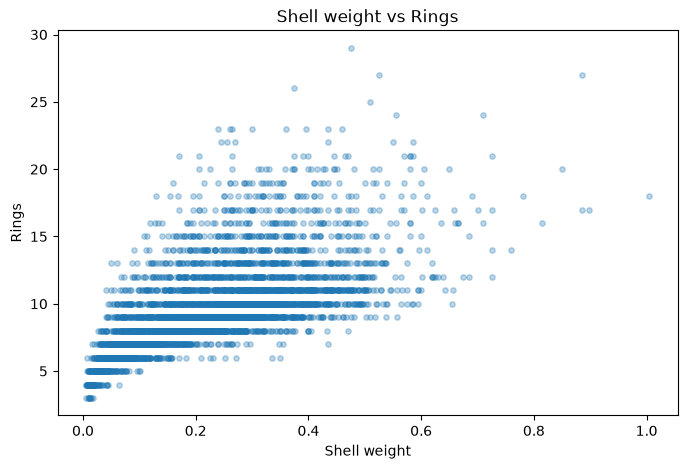

In [115]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,5))
plt.scatter(df['Shell weight'], df['Rings'], alpha=0.3, s=15)
plt.xlabel("Shell weight")
plt.ylabel("Rings")
plt.title("Shell weight vs Rings")
plt.show()

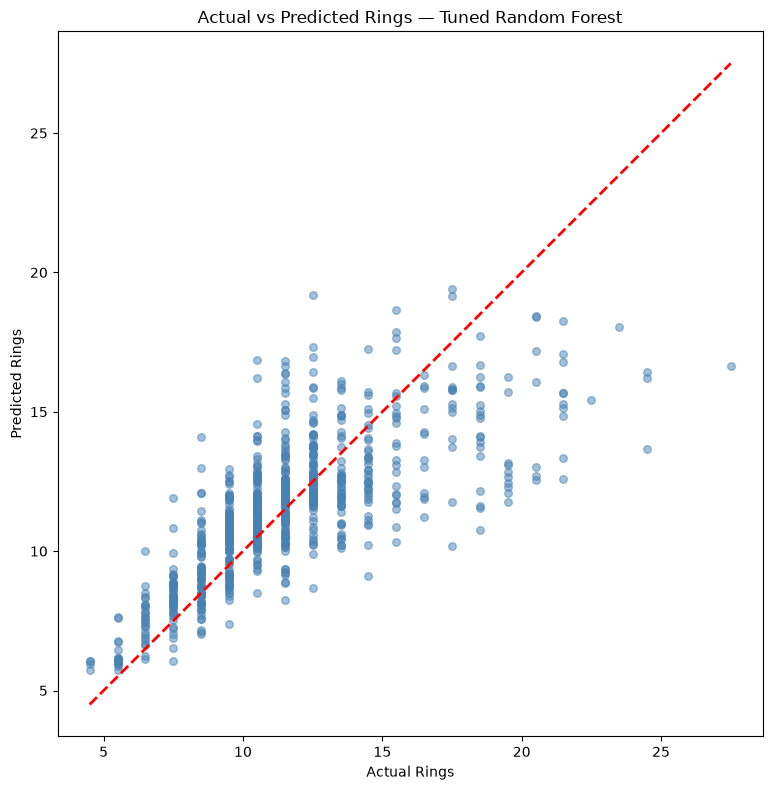

In [116]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, rf_model.predict(X_test), alpha=0.5, s=30, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs Predicted Rings — Tuned Random Forest")
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

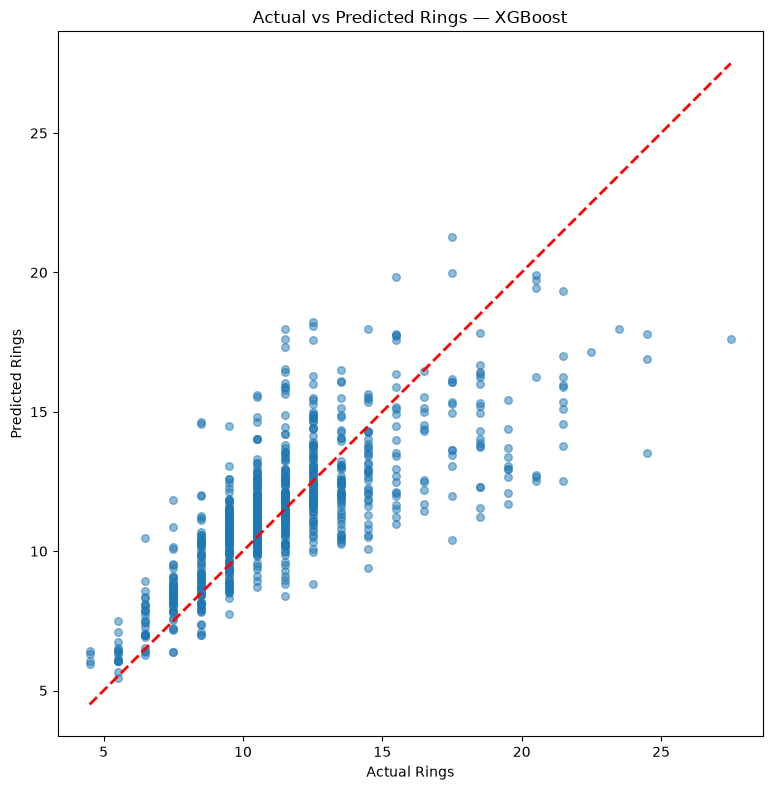

In [117]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    xgb_model.predict(X_test),
    alpha=0.5,
    s=30
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs Predicted Rings — XGBoost")

plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

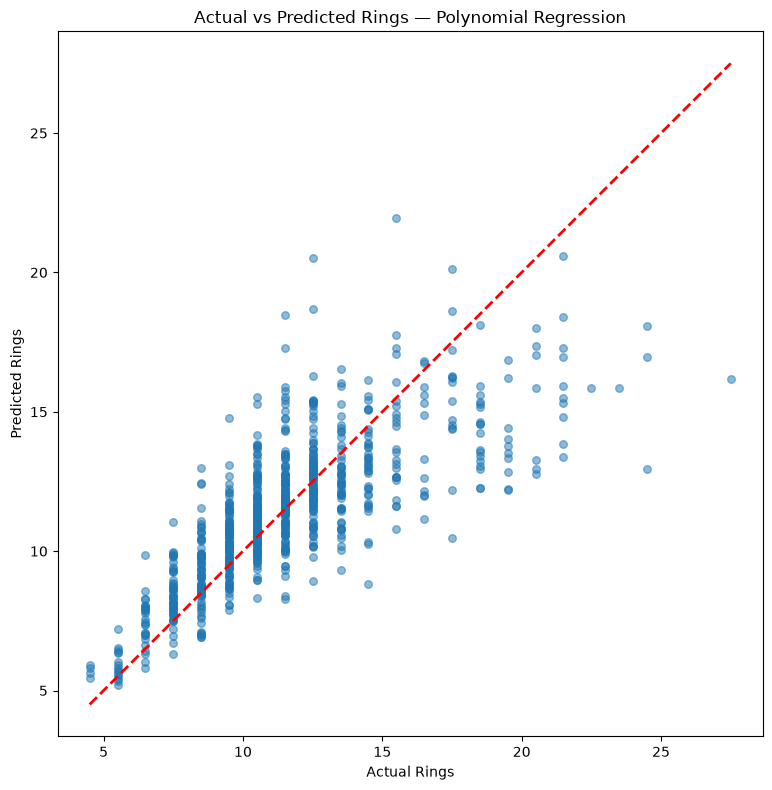

In [118]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    poly_model.predict(X_test_poly),
    alpha=0.5,
    s=30
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs Predicted Rings — Polynomial Regression")

plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()